# Bayesian Network — Urban Flood Stress

**Objective:** Exploratory probabilistic dependency model to understand
relationships among flooding occurrence, infrastructure stress, precipitation,
tides, and socioeconomic vulnerability in New York City.

This notebook is *not* a causal discovery exercise. The learned DAG represents
conditional independence structure inferred from data, guided by weak
domain-informed constraints. Results should be interpreted as probabilistic
dependencies and hypothesis generators — **not causal claims**.

---

**Approach:**
- Hill-Climb Search + BIC score (fast, locally optimal)
- 14 curated variables selected from across ML pipeline importance rankings
- Quantile + domain-aware discretization
- Physics-based forbidden-edge constraints via `ExpertKnowledge`
- CPT estimation via Maximum Likelihood (default pgmpy estimator)

**Libraries:** `pgmpy 1.1.2`, `networkx`, `scipy`, `statsmodels`, `seaborn`


In [2]:
import os
import warnings
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx

# pgmpy 1.1.2 API
from pgmpy.estimators import BIC, HillClimbSearch
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.causal_discovery import ExpertKnowledge
from pgmpy.inference import VariableElimination

warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.4f}".format)

# ── Paths ──────────────────────────────────────────────────────────────────
ROOT     = Path("..").resolve()
DATA_DIR = ROOT / "data/processed/modeling/filtered"
OUT_DIR  = ROOT / "data/processed/modeling/bayesian"
FIG_DIR  = ROOT / "figures/bayesian_network"

for d in [OUT_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Parameters ─────────────────────────────────────────────────────────────
RANDOM_STATE    = 42
SAMPLE_SIZE     = 15_000   # rows used for structure learning
MAX_ITER        = 2_000    # Hill-Climb iterations
MAX_INDEGREE    = 4        # max parents per node

print("Environment ready.")
print(f"  Data   : {DATA_DIR}")
print(f"  Outputs: {OUT_DIR}")
print(f"  Figures: {FIG_DIR}")


Environment ready.
  Data   : /home/map10194/Documents/urban-flood-stress/data/processed/modeling/filtered
  Outputs: /home/map10194/Documents/urban-flood-stress/data/processed/modeling/bayesian
  Figures: /home/map10194/Documents/urban-flood-stress/figures/bayesian_network


## 1  Data Loading

In [3]:
df_raw = pd.read_parquet(DATA_DIR / "strict_main.parquet")

print(f"Loaded: {len(df_raw):,} rows × {df_raw.shape[1]} columns")
print(f"  Flood events (occurrence=True) : {df_raw['occurrence'].sum():,}")
print(f"  Non-flood events               : {(~df_raw['occurrence']).sum():,}")
print(f"  Date range                     : {df_raw['start'].min().date()} → {df_raw['start'].max().date()}")


Loaded: 69,738 rows × 163 columns
  Flood events (occurrence=True) : 34,870
  Non-flood events               : 34,868
  Date range                     : 2010-01-01 → 2026-05-05


## 2  Variable Selection

Variables were chosen based on:

1. **Consistent importance** across Random Forest, SHAP, and permutation rankings
   (notebooks 14–16).
2. **Physical interpretability** — each node has a clear role in the flood system.
3. **Low collinearity** — correlated proxies were pruned (see VIF below).
4. **Data availability** — variables with >10% missingness were excluded.

| Category | BN Variable | Source column |
|----------|-------------|---------------|
| Flooding | `flood_occurrence` | `occurrence` |
| Flooding | `complaint_count` | `intensity` |
| Flooding | `event_resolved` | `resolution_bool` |
| Flooding | `event_duration` | `resolution_hours` |
| Hydro | `precip_total` | `prec_depth_total` |
| Hydro | `precip_peak` | `prec_intensity_max` |
| Hydro | `tide_level` | `tide_level_m_max` |
| Terrain | `elevation` | `dem_mean` |
| Terrain | `slope` | `dem_slope` |
| Terrain | `fema_zone_overlap` | `fema_overlap_ft` |
| Network | `edge_betweenness` | `segment_edge_betweenness` (log₁₀) |
| Network | `travel_time` | `segment_travel_time_s` |
| Infra | `drain_distance` | `catch_basin_nearest_ft` |
| Socioeco | `median_income` | `census_median_household_income` |

**Excluded variables and rationale:**

| Variable | Reason |
|----------|--------|
| `prec_intensity_mean` | Collinear with `precip_total` and `precip_peak` |
| `prec_duration_total` | Collinear with `precip_total` (ρ > 0.7) |
| `n_prec` | Coarse count, superseded by `precip_total` |
| `shore_dist_ft` | Correlated with `elevation` and `fema_zone_overlap` |
| `outfall_nearest_ft` | Correlated with `drain_distance` (Spearman ρ ≈ 0.6) |
| `pct_giant_component_loss` | 100% missing in analysis view |
| `census_poverty_rate` | Correlated with `median_income`; income retained as primary |
| `census_renter_share` | Secondary socioeconomic proxy; excluded for parsimony |
| `census_no_vehicle_share` | Secondary socioeconomic proxy; excluded for parsimony |
| `fema_overlap_share` | Ratio version of `fema_zone_overlap`; redundant |


In [4]:
# ── Column mapping: raw → BN name ─────────────────────────────────────────
RAW_TO_BN = {
    "occurrence"                    : "flood_occurrence",
    "intensity"                     : "complaint_count",
    "resolution_bool"               : "event_resolved",
    "resolution_hours"              : "event_duration",
    "prec_depth_total"              : "precip_total",
    "prec_intensity_max"            : "precip_peak",
    "tide_level_m_max"              : "tide_level",
    "dem_mean"                      : "elevation",
    "dem_slope"                     : "slope",
    "fema_overlap_ft"               : "fema_zone_overlap",
    "segment_edge_betweenness"      : "edge_betweenness",
    "segment_travel_time_s"         : "travel_time",
    "catch_basin_nearest_ft"        : "drain_distance",
    "census_median_household_income": "median_income",
}

# ── Node category tags (for plot coloring) ────────────────────────────────
NODE_CATEGORY = {
    "flood_occurrence" : "flooding",
    "complaint_count"  : "flooding",
    "event_resolved"   : "flooding",
    "event_duration"   : "flooding",
    "precip_total"     : "hydro",
    "precip_peak"      : "hydro",
    "tide_level"       : "hydro",
    "elevation"        : "terrain",
    "slope"            : "terrain",
    "fema_zone_overlap": "terrain",
    "edge_betweenness" : "network",
    "travel_time"      : "network",
    "drain_distance"   : "infrastructure",
    "median_income"    : "socioeconomic",
}

CATEGORY_COLOR = {
    "flooding"      : "#E74C3C",
    "hydro"         : "#3498DB",
    "terrain"       : "#27AE60",
    "network"       : "#E67E22",
    "infrastructure": "#8E44AD",
    "socioeconomic" : "#16A085",
}

# ── Extract & rename ──────────────────────────────────────────────────────
df = df_raw[list(RAW_TO_BN.keys())].rename(columns=RAW_TO_BN).copy()
print(f"Working dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.dtypes


Working dataset: 69,738 rows × 14 columns


flood_occurrence        bool
complaint_count        Int64
event_resolved          bool
event_duration       float64
precip_total         float64
precip_peak          float64
tide_level           float64
elevation            float64
slope                float64
fema_zone_overlap    float64
edge_betweenness     float64
travel_time          float64
drain_distance       float64
median_income        float64
dtype: object

## 3  Preprocessing & Feature Reduction

In [5]:
# ── 3.1  Missingness summary ──────────────────────────────────────────────
miss = df.isnull().sum()
miss_pct = miss / len(df) * 100
miss_df = pd.DataFrame({"missing_n": miss, "missing_pct": miss_pct}).sort_values(
    "missing_pct", ascending=False
)
miss_df["note"] = miss_df["missing_pct"].apply(
    lambda p: "no_flood rows have no resolution" if p > 40
    else ("impute with median" if p > 0 else "complete")
)
print(miss_df.to_string())
miss_df.to_csv(OUT_DIR / "missingness_summary.csv")


                   missing_n  missing_pct                              note
event_duration         35196      50.4689  no_flood rows have no resolution
tide_level              5396       7.7375                impute with median
median_income             14       0.0201                impute with median
slope                      2       0.0029                impute with median
elevation                  2       0.0029                impute with median
flood_occurrence           0       0.0000                          complete
precip_peak                0       0.0000                          complete
precip_total               0       0.0000                          complete
event_resolved             0       0.0000                          complete
complaint_count            0       0.0000                          complete
fema_zone_overlap          0       0.0000                          complete
edge_betweenness           0       0.0000                          complete
travel_time 

In [6]:
# ── 3.2  Impute small missingness with median ─────────────────────────────
for col in ["tide_level", "elevation", "slope", "median_income"]:
    n_miss = df[col].isnull().sum()
    if n_miss > 0:
        med = df[col].median()
        df[col] = df[col].fillna(med)
        print(f"  {col}: imputed {n_miss:,} NaN with median={med:.4f}")

print(f"\nRemaining NaN (expect only event_duration ~50%):")
remaining = df.isnull().sum()
print(remaining[remaining > 0].to_string())


  tide_level: imputed 5,396 NaN with median=1.7886
  elevation: imputed 2 NaN with median=9.3700
  slope: imputed 2 NaN with median=0.0061
  median_income: imputed 14 NaN with median=73189.0000

Remaining NaN (expect only event_duration ~50%):
event_duration    35196


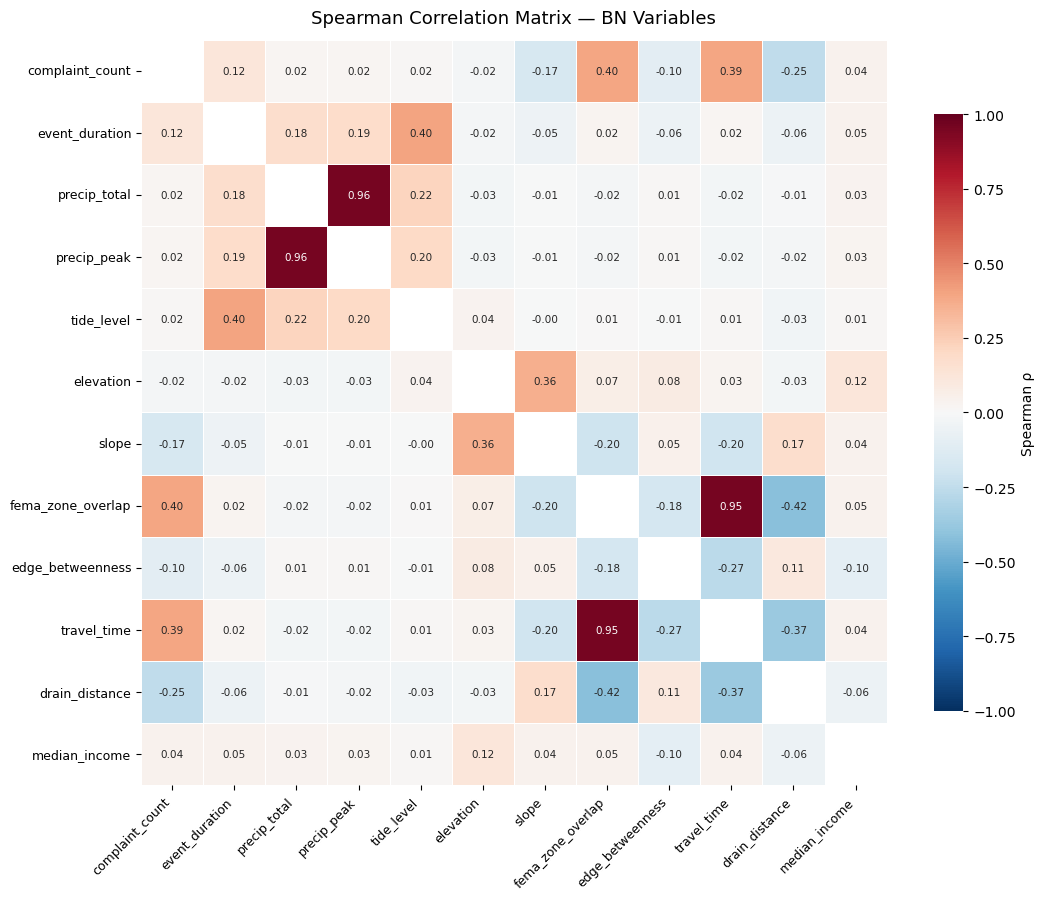

Saved: fig_correlation_matrix


In [7]:
# ── 3.3  Spearman correlation matrix ─────────────────────────────────────
NUMERIC_VARS = [
    "complaint_count", "event_duration",
    "precip_total", "precip_peak", "tide_level",
    "elevation", "slope", "fema_zone_overlap",
    "edge_betweenness", "travel_time", "drain_distance", "median_income",
]

corr = df[NUMERIC_VARS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.eye(len(NUMERIC_VARS), dtype=bool)
sns.heatmap(
    corr, mask=mask, ax=ax,
    cmap="RdBu_r", vmin=-1, vmax=1, center=0,
    annot=True, fmt=".2f", annot_kws={"size": 7.5},
    linewidths=0.4, square=True,
    cbar_kws={"shrink": 0.8, "label": "Spearman ρ"},
)
ax.set_title("Spearman Correlation Matrix — BN Variables", fontsize=13, pad=12)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()

for fmt in ["png", "pdf", "svg"]:
    plt.savefig(FIG_DIR / f"fig_correlation_matrix.{fmt}", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_correlation_matrix")


In [8]:
# ── 3.4  Variance Inflation Factor ───────────────────────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor

df_vif = df[NUMERIC_VARS].dropna()
# Cast to plain float64 — pandas nullable dtypes (Float64, Int64) break statsmodels
X_raw = df_vif.astype(float).to_numpy(dtype=np.float64)
X_std = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)

vif_df = pd.DataFrame({
    "variable": NUMERIC_VARS,
    "VIF": [variance_inflation_factor(X_std, i)
            for i in range(len(NUMERIC_VARS))]
}).sort_values("VIF", ascending=False).reset_index(drop=True)

print("=== VIF Table ===")
print(vif_df.to_string(index=False))
vif_df.to_csv(OUT_DIR / "vif_table.csv", index=False)

high_vif = vif_df[vif_df["VIF"] > 5]
if len(high_vif):
    print(f"\n⚠  Variables with VIF > 5: {high_vif['variable'].tolist()}")
    print("   Retained here due to domain importance.")
else:
    print("\n✓  All VIF < 5 — no severe multicollinearity.")


=== VIF Table ===
         variable    VIF
      travel_time 8.5433
fema_zone_overlap 8.5383
     precip_total 2.6138
      precip_peak 2.1034
   event_duration 1.3259
  complaint_count 1.0651
            slope 1.0634
        elevation 1.0628
       tide_level 1.0418
   drain_distance 1.0282
 edge_betweenness 1.0275
    median_income 1.0209

⚠  Variables with VIF > 5: ['travel_time', 'fema_zone_overlap']
   Retained here due to domain importance.


## 4  Discretization

Bayesian Networks require discrete variables. We combine:
- **Quantile binning** for variables without natural physical breakpoints
- **Domain-based thresholds** where physically meaningful

| Variable | Method | Bins |
|----------|--------|------|
| `flood_occurrence` | Binary | no / yes |
| `complaint_count` | Domain: 0/1/2–3/4+ | none / low / moderate / high |
| `event_resolved` | Domain + NaN handling | no_flood / resolved / unresolved |
| `event_duration` | Domain thresholds (h) | no_flood / short / medium / long / very_long |
| `precip_total` | Domain (mm) | dry / light / moderate / heavy |
| `precip_peak` | Domain (mm/h) | calm / light / moderate / intense |
| `tide_level` | Domain (m NAVD88) | normal / elevated / high / extreme |
| `elevation` | Quantile 4-bin | very_low / low / medium / high |
| `slope` | Quantile 4-bin | flat / gentle / moderate / steep |
| `fema_zone_overlap` | Domain (ft) | none / low / moderate / high |
| `edge_betweenness` | Quantile on log₁₀ | low / medium / high / critical |
| `travel_time` | Quantile 4-bin (s) | short / medium / long / very_long |
| `drain_distance` | Quantile 4-bin (ft) | near / moderate / far / very_far |
| `median_income` | Quantile 4-bin ($) | low / moderate / high / very_high |


In [9]:
# ── Discretization helper ─────────────────────────────────────────────────
def qbin(series, labels):
    """Equal-frequency binning into len(labels) bins."""
    n = len(labels)
    edges = np.nanquantile(series.dropna(), np.linspace(0, 1, n + 1))
    edges[0]  -= 1e-9
    edges[-1] += 1e-9
    edges = np.unique(edges)
    actual_labels = labels[:len(edges) - 1]
    return pd.cut(series, bins=edges, labels=actual_labels,
                  include_lowest=True).astype(str)


disc = pd.DataFrame(index=df.index)

# ── Flooding / Response ───────────────────────────────────────────────────
disc["flood_occurrence"] = df["flood_occurrence"].map(
    {True: "yes", False: "no", 1: "yes", 0: "no"}
)

disc["complaint_count"] = pd.cut(
    df["complaint_count"].astype(float),
    bins=[-0.1, 0.5, 1.5, 3.5, 9999],
    labels=["none", "low", "moderate", "high"],
).astype(str)

flood_mask = df["flood_occurrence"].isin([True, 1])

disc["event_resolved"] = "no_flood"
disc.loc[flood_mask & (df["event_resolved"] == True),  "event_resolved"] = "resolved"
disc.loc[flood_mask & (df["event_resolved"] == False), "event_resolved"] = "unresolved"

disc["event_duration"] = "no_flood"
disc.loc[flood_mask & df["event_duration"].isnull(), "event_duration"] = "unknown"
dur = df.loc[flood_mask & df["event_duration"].notnull(), "event_duration"]
disc.loc[dur.index, "event_duration"] = pd.cut(
    dur,
    bins=[-0.001, 6, 24, 72, 99999],
    labels=["short", "medium", "long", "very_long"],
).astype(str).values

# ── Precipitation / Tide ──────────────────────────────────────────────────
disc["precip_total"] = pd.cut(
    df["precip_total"],
    bins=[-0.001, 0.01, 10, 40, 9999],
    labels=["dry", "light", "moderate", "heavy"],
).astype(str)

disc["precip_peak"] = pd.cut(
    df["precip_peak"],
    bins=[-0.001, 0.01, 2, 8, 9999],
    labels=["calm", "light", "moderate", "intense"],
).astype(str)

disc["tide_level"] = pd.cut(
    df["tide_level"],
    bins=[-99, 1.3, 2.0, 2.5, 99],
    labels=["normal", "elevated", "high", "extreme"],
).astype(str)

# ── Terrain ───────────────────────────────────────────────────────────────
disc["elevation"]        = qbin(df["elevation"], ["very_low", "low", "medium", "high"])
disc["slope"]            = qbin(df["slope"],     ["flat", "gentle", "moderate", "steep"])

disc["fema_zone_overlap"] = pd.cut(
    df["fema_zone_overlap"],
    bins=[-0.001, 0.01, 200, 500, 9999],
    labels=["none", "low", "moderate", "high"],
).astype(str)

# ── Network / Infrastructure ──────────────────────────────────────────────
log_eb = np.log10(df["edge_betweenness"].clip(lower=1))
disc["edge_betweenness"] = qbin(log_eb, ["low", "medium", "high", "critical"])
disc["travel_time"]      = qbin(df["travel_time"],    ["short", "medium", "long", "very_long"])
disc["drain_distance"]   = qbin(df["drain_distance"], ["near", "moderate", "far", "very_far"])

# ── Socioeconomic ─────────────────────────────────────────────────────────
disc["median_income"] = qbin(df["median_income"], ["low", "moderate", "high", "very_high"])

# ── Validate ──────────────────────────────────────────────────────────────
disc = disc.replace("nan", np.nan)
n_before = len(disc)
disc = disc.dropna()
disc = disc.astype(str)
print(f"Discretized: {n_before:,} → {len(disc):,} rows (dropped {n_before - len(disc):,} with NaN)")

print("\nValue counts per variable:")
for col in disc.columns:
    vc = disc[col].value_counts().to_dict()
    print(f"  {col:20s}: {vc}")


Discretized: 69,738 → 69,738 rows (dropped 0 with NaN)

Value counts per variable:
  flood_occurrence    : {'yes': 34870, 'no': 34868}
  complaint_count     : {'none': 34868, 'low': 32523, 'moderate': 2156, 'high': 191}
  event_resolved      : {'no_flood': 34868, 'resolved': 34542, 'unresolved': 328}
  event_duration      : {'no_flood': 34868, 'short': 12265, 'medium': 11372, 'long': 6849, 'very_long': 4056, 'unknown': 328}
  precip_total        : {'dry': 34179, 'heavy': 22793, 'moderate': 8842, 'light': 3924}
  precip_peak         : {'calm': 34179, 'moderate': 18457, 'light': 8648, 'intense': 8454}
  tide_level          : {'elevated': 39441, 'high': 13317, 'normal': 9874, 'extreme': 7106}
  elevation           : {'low': 17436, 'high': 17435, 'very_low': 17435, 'medium': 17432}
  slope               : {'moderate': 17436, 'flat': 17435, 'gentle': 17435, 'steep': 17432}
  fema_zone_overlap   : {'moderate': 30444, 'low': 24525, 'high': 14708, 'none': 61}
  edge_betweenness    : {'high': 1

In [10]:
# ── Document thresholds ───────────────────────────────────────────────────
import json as _json

thresholds = {
    "flood_occurrence"  : "binary: no / yes",
    "complaint_count"   : "0=none | 1=low | 2–3=moderate | 4+=high",
    "event_resolved"    : "no_flood (occurrence=no) | resolved | unresolved",
    "event_duration"    : "no_flood | short (<6h) | medium (6–24h) | long (24–72h) | very_long (>72h) | unknown",
    "precip_total"      : "dry (0mm) | light (0–10mm) | moderate (10–40mm) | heavy (>40mm)",
    "precip_peak"       : "calm (0mm/h) | light (0–2mm/h) | moderate (2–8mm/h) | intense (>8mm/h)",
    "tide_level"        : "normal (<1.3m) | elevated (1.3–2.0m) | high (2.0–2.5m) | extreme (>2.5m)",
    "elevation"         : "quantile 4-bin (dem_mean ft): very_low | low | medium | high",
    "slope"             : "quantile 4-bin (dem_slope): flat | gentle | moderate | steep",
    "fema_zone_overlap" : "none (0ft) | low (0–200ft) | moderate (200–500ft) | high (>500ft)",
    "edge_betweenness"  : "quantile 4-bin on log10(segment_edge_betweenness): low | medium | high | critical",
    "travel_time"       : "quantile 4-bin (segment_travel_time_s): short | medium | long | very_long",
    "drain_distance"    : "quantile 4-bin (catch_basin_nearest_ft): near | moderate | far | very_far",
    "median_income"     : "quantile 4-bin (census_median_household_income): low | moderate | high | very_high",
}

with open(OUT_DIR / "discretization_thresholds.json", "w") as f:
    _json.dump(thresholds, f, indent=2)
print("Saved: discretization_thresholds.json")


Saved: discretization_thresholds.json


## 5  BN Structure Learning

**Method:** Hill-Climb Search with BIC (Bayesian Information Criterion) scoring.

BIC penalizes model complexity and favours sparser, less overfit graphs.

**Domain constraints via `ExpertKnowledge(forbidden_edges=...)`:**

1. *Flooding variables cannot cause physical drivers* — precipitation,
   tide, terrain, and infrastructure are pre-event structural features.
2. *Meteorological variables are treated as exogenous* — terrain and
   socioeconomic structure cannot drive NYC precipitation or tidal forcing.
3. *Flood outcomes (complaint_count, event_resolved, event_duration) cannot
   point back to flood_occurrence* — they are downstream consequences.


In [11]:
# ── Define forbidden edges ────────────────────────────────────────────────
FLOODING_VARS    = ["flood_occurrence", "complaint_count", "event_resolved", "event_duration"]
FLOOD_OUTCOMES   = ["complaint_count", "event_resolved", "event_duration"]  # downstream of occurrence
METEOROLOGICAL   = ["precip_total", "precip_peak", "tide_level"]
STRUCTURAL       = ["elevation", "slope", "fema_zone_overlap",
                    "edge_betweenness", "travel_time", "drain_distance", "median_income"]
ALL_DRIVERS      = METEOROLOGICAL + STRUCTURAL

forbidden = []

# (1) Flooding variables cannot point to any physical driver
for fv in FLOODING_VARS:
    for dv in ALL_DRIVERS:
        forbidden.append((fv, dv))

# (2) Structural variables cannot point to meteorological (meteo is exogenous)
for sv in STRUCTURAL:
    for mv in METEOROLOGICAL:
        forbidden.append((sv, mv))

# (3) Downstream flood outcomes cannot point back to flood_occurrence
#     (complaint_count, event_resolved, event_duration are consequences, not causes)
for ov in FLOOD_OUTCOMES:
    forbidden.append((ov, "flood_occurrence"))

expert_knowledge = ExpertKnowledge(forbidden_edges=forbidden)

print(f"Forbidden edges: {len(forbidden)}")
print("Example constraints:")
for e in [(fv, dv) for fv in FLOOD_OUTCOMES for dv in ["flood_occurrence"]][:3]:
    print(f"  {e[0]} → {e[1]}  ✗ (outcome cannot cause occurrence)")
for e in [("precip_total", "elevation"), ("elevation", "precip_total")][:2]:
    arrow = "✗ forbidden" if (e[0] in STRUCTURAL and e[1] in METEOROLOGICAL) else "✓ allowed"
    print(f"  {e[0]} → {e[1]}  ({arrow})")


Forbidden edges: 64
Example constraints:
  complaint_count → flood_occurrence  ✗ (outcome cannot cause occurrence)
  event_resolved → flood_occurrence  ✗ (outcome cannot cause occurrence)
  event_duration → flood_occurrence  ✗ (outcome cannot cause occurrence)
  precip_total → elevation  (✓ allowed)
  elevation → precip_total  (✗ forbidden)


In [12]:
# ── Subsample for structure learning ─────────────────────────────────────
rng = np.random.default_rng(RANDOM_STATE)
idx = rng.choice(len(disc), size=min(SAMPLE_SIZE, len(disc)), replace=False)
disc_sample = disc.iloc[idx].reset_index(drop=True)

print(f"Structure-learning sample: {len(disc_sample):,} rows")
print(f"Full dataset for parameter learning: {len(disc):,} rows")

# ── Hill-Climb Search + BIC ───────────────────────────────────────────────
scorer   = BIC(disc_sample)
searcher = HillClimbSearch(disc_sample)

print("\nRunning Hill-Climb Search + BIC …")
best_dag = searcher.estimate(
    scoring_method=scorer,
    expert_knowledge=expert_knowledge,
    max_indegree=MAX_INDEGREE,
    max_iter=MAX_ITER,
    show_progress=True,
)

edges   = list(best_dag.edges())
dag_nodes = list(best_dag.nodes())
print(f"\n✓ Learned DAG: {len(dag_nodes)} nodes, {len(edges)} edges")
print("\nEdge list (sorted):")
for u, v in sorted(edges):
    print(f"  {u:25s} → {v}")


Structure-learning sample: 15,000 rows
Full dataset for parameter learning: 69,738 rows

Running Hill-Climb Search + BIC …


  1%|          | 18/2000 [00:00<00:59, 33.18it/s]


✓ Learned DAG: 14 nodes, 18 edges

Edge list (sorted):
  drain_distance            → edge_betweenness
  drain_distance            → flood_occurrence
  drain_distance            → slope
  drain_distance            → travel_time
  elevation                 → median_income
  event_duration            → complaint_count
  event_resolved            → event_duration
  fema_zone_overlap         → drain_distance
  fema_zone_overlap         → elevation
  fema_zone_overlap         → flood_occurrence
  fema_zone_overlap         → travel_time
  flood_occurrence          → event_resolved
  precip_peak               → precip_total
  precip_total              → tide_level
  slope                     → elevation
  tide_level                → event_duration
  travel_time               → edge_betweenness
  travel_time               → slope


## 6  Parameter Learning — Conditional Probability Tables

In [13]:
# Fit the BN on the FULL discretized dataset (MLE is the default estimator)
bn = DiscreteBayesianNetwork(edges)

# Add isolated nodes (no edges from structure learning) so all variables appear
all_bn_vars = list(disc.columns)
for node in all_bn_vars:
    if node not in bn.nodes():
        bn.add_node(node)

missing_nodes = [n for n in bn.nodes() if n not in disc.columns]
if missing_nodes:
    print(f"⚠ Nodes not in disc: {missing_nodes}")
else:
    bn.fit(disc)
    print(f"✓ BN fitted on {len(disc):,} rows (MLE)")

print(f"\nNodes : {len(bn.nodes())}")
print(f"Edges : {len(bn.edges())}")


✓ BN fitted on 69,738 rows (MLE)

Nodes : 14
Edges : 18


In [14]:
# ── CPT Summary ───────────────────────────────────────────────────────────
print("=== Conditional Probability Tables ===\n")

for cpd in sorted(bn.cpds, key=lambda c: c.variable):
    parents = cpd.variables[1:]
    print(f"CPD({cpd.variable} | {parents if parents else 'root'}):")
    print(cpd)
    print()

    # Save CPT to CSV
    states_var = cpd.state_names[cpd.variable]
    if len(cpd.variables) == 1:
        # Root node
        cpt_df = pd.Series(cpd.values, index=states_var, name=cpd.variable).to_frame("probability")
    else:
        # Child node – unpack values along parent combinations
        from itertools import product as iproduct
        parent_states = [cpd.state_names[p] for p in parents]
        combos = list(iproduct(*parent_states))
        rows = []
        for col_idx, combo in enumerate(combos):
            for row_idx, state in enumerate(states_var):
                prob = cpd.values[row_idx, col_idx] if cpd.values.ndim == 2 else cpd.values[row_idx]
                rows.append({cpd.variable: state, **dict(zip(parents, combo)), "probability": prob})
        cpt_df = pd.DataFrame(rows)

    cpt_df.to_csv(OUT_DIR / f"cpt_{cpd.variable}.csv", index=False)

print(f"Saved {len(bn.cpds)} CPT files to {OUT_DIR}")


=== Conditional Probability Tables ===

CPD(complaint_count | ['event_duration']):
+---------------------------+-----+---------------------------+
| event_duration            | ... | event_duration(very_long) |
+---------------------------+-----+---------------------------+
| complaint_count(high)     | ... | 0.016025641025641024      |
+---------------------------+-----+---------------------------+
| complaint_count(low)      | ... | 0.8715483234714004        |
+---------------------------+-----+---------------------------+
| complaint_count(moderate) | ... | 0.11242603550295859       |
+---------------------------+-----+---------------------------+
| complaint_count(none)     | ... | 0.0                       |
+---------------------------+-----+---------------------------+

CPD(drain_distance | ['fema_zone_overlap']):
+--------------------------+-----+-------------------------+
| fema_zone_overlap        | ... | fema_zone_overlap(none) |
+--------------------------+-----+-----------

## 7  Model Diagnostics

In [15]:
import networkx as nx

G_nx = nx.DiGraph(bn.edges())

node_stats = []
for node in sorted(bn.nodes()):
    parents  = list(bn.get_parents(node))
    children = list(G_nx.successors(node))
    states   = list(disc[node].unique()) if node in disc.columns else []
    node_stats.append({
        "node"          : node,
        "category"      : NODE_CATEGORY.get(node, "unknown"),
        "n_parents"     : len(parents),
        "n_children"    : len(children),
        "parents"       : "; ".join(parents),
        "children"      : "; ".join(children),
        "n_states"      : len(states),
        "states"        : "; ".join(sorted(states)),
        "in_degree"     : G_nx.in_degree(node),
        "out_degree"    : G_nx.out_degree(node),
    })

node_stats_df = pd.DataFrame(node_stats).sort_values(["category", "node"])
print(node_stats_df.to_string(index=False))
node_stats_df.to_csv(OUT_DIR / "node_statistics.csv", index=False)


             node       category  n_parents  n_children                           parents                                                 children  n_states                                            states  in_degree  out_degree
  complaint_count       flooding          1           0                    event_duration                                                                  4                         high; low; moderate; none          1           0
   event_duration       flooding          2           1        event_resolved; tide_level                                          complaint_count         6 long; medium; no_flood; short; unknown; very_long          2           1
   event_resolved       flooding          1           1                  flood_occurrence                                           event_duration         3                    no_flood; resolved; unresolved          1           1
 flood_occurrence       flooding          2           1 fema_zone_overlap; drain

In [16]:
# ── Adjacency matrix ──────────────────────────────────────────────────────
all_nodes = sorted(bn.nodes())
adj = pd.DataFrame(0, index=all_nodes, columns=all_nodes, dtype=int)
for u, v in bn.edges():
    adj.loc[u, v] = 1

print("Adjacency matrix  (row→col  =  edge u→v):")
print(adj.to_string())
adj.to_csv(OUT_DIR / "adjacency_matrix.csv")

# Edge list
edge_df = pd.DataFrame(bn.edges(), columns=["source", "target"])
edge_df["source_category"] = edge_df["source"].map(NODE_CATEGORY)
edge_df["target_category"] = edge_df["target"].map(NODE_CATEGORY)
edge_df.to_csv(OUT_DIR / "edge_list.csv", index=False)
print(f"\nEdge list saved ({len(edge_df)} edges).")


Adjacency matrix  (row→col  =  edge u→v):
                   complaint_count  drain_distance  edge_betweenness  elevation  event_duration  event_resolved  fema_zone_overlap  flood_occurrence  median_income  precip_peak  precip_total  slope  tide_level  travel_time
complaint_count                  0               0                 0          0               0               0                  0                 0              0            0             0      0           0            0
drain_distance                   0               0                 1          0               0               0                  0                 1              0            0             0      1           0            1
edge_betweenness                 0               0                 0          0               0               0                  0                 0              0            0             0      0           0            0
elevation                        0               0                

In [17]:
# ── Save BN model ─────────────────────────────────────────────────────────
with open(OUT_DIR / "bayesian_network.pkl", "wb") as fh:
    pickle.dump(bn, fh)
print("✓ Saved bayesian_network.pkl")
print("\nLoad with:")
print("  import pickle")
print("  with open('data/processed/modeling/bayesian/bayesian_network.pkl','rb') as f:")
print("      bn = pickle.load(f)")


✓ Saved bayesian_network.pkl

Load with:
  import pickle
  with open('data/processed/modeling/bayesian/bayesian_network.pkl','rb') as f:
      bn = pickle.load(f)


## 8  Network Visualization

Node color encodes variable category:

| Color | Category |
|-------|----------|
| Red | Flooding / response |
| Blue | Hydrological |
| Green | Terrain |
| Orange | Network/connectivity |
| Purple | Infrastructure |
| Teal | Socioeconomic |


In [18]:
def draw_bn(model, title="Bayesian Network", figsize=(14, 9),
            highlight_nodes=None, fname=None):
    """Visualise a DiscreteBayesianNetwork with a fixed hierarchical layout."""
    G = nx.DiGraph(model.edges())

    # Fixed hierarchical positions
    FIXED_POS = {
        "precip_total"     : (0.0, 4.0),
        "precip_peak"      : (2.0, 4.0),
        "tide_level"       : (4.0, 4.0),
        "elevation"        : (0.0, 3.0),
        "slope"            : (1.5, 3.0),
        "fema_zone_overlap": (3.0, 3.0),
        "drain_distance"   : (0.0, 2.0),
        "edge_betweenness" : (1.5, 2.0),
        "travel_time"      : (3.0, 2.0),
        "median_income"    : (4.5, 2.0),
        "flood_occurrence" : (2.2, 1.0),
        "complaint_count"  : (0.5, 0.0),
        "event_resolved"   : (2.2, 0.0),
        "event_duration"   : (4.0, 0.0),
    }

    pos = {}
    for n in G.nodes():
        if n in FIXED_POS:
            pos[n] = FIXED_POS[n]
        else:
            pos[n] = (5.0, 5.0)  # fallback

    node_colors = [CATEGORY_COLOR.get(NODE_CATEGORY.get(n, ""), "#AAAAAA")
                   for n in G.nodes()]
    node_sizes  = [3000 if (highlight_nodes and n in highlight_nodes) else 2200
                   for n in G.nodes()]

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_facecolor("#F8F9FA")
    fig.patch.set_facecolor("#F8F9FA")

    nx.draw_networkx_nodes(G, pos, ax=ax,
        node_color=node_colors, node_size=node_sizes, alpha=0.92)
    nx.draw_networkx_labels(G, pos, ax=ax,
        font_size=8.5, font_weight="bold", font_color="white")
    nx.draw_networkx_edges(G, pos, ax=ax,
        edge_color="#333333", arrows=True, arrowsize=22, arrowstyle="-|>",
        width=1.8, connectionstyle="arc3,rad=0.06",
        min_source_margin=28, min_target_margin=28)

    if highlight_nodes:
        hn = [n for n in highlight_nodes if n in G.nodes()]
        nx.draw_networkx_nodes(G, pos, nodelist=hn, ax=ax,
            node_color=[CATEGORY_COLOR.get(NODE_CATEGORY.get(n,""),"#AAA") for n in hn],
            node_size=3400, linewidths=4, edgecolors="black", alpha=1.0)

    legend_handles = [
        mpatches.Patch(color=c, label=cat.capitalize())
        for cat, c in CATEGORY_COLOR.items()
    ]
    ax.legend(handles=legend_handles, loc="upper left", fontsize=9,
              framealpha=0.9, title="Category")
    ax.set_title(title, fontsize=15, fontweight="bold", pad=14)
    ax.axis("off")
    plt.tight_layout()

    if fname:
        for fmt in ["png", "pdf", "svg"]:
            plt.savefig(FIG_DIR / f"{fname}.{fmt}", dpi=180, bbox_inches="tight")
    plt.show()
    return fig


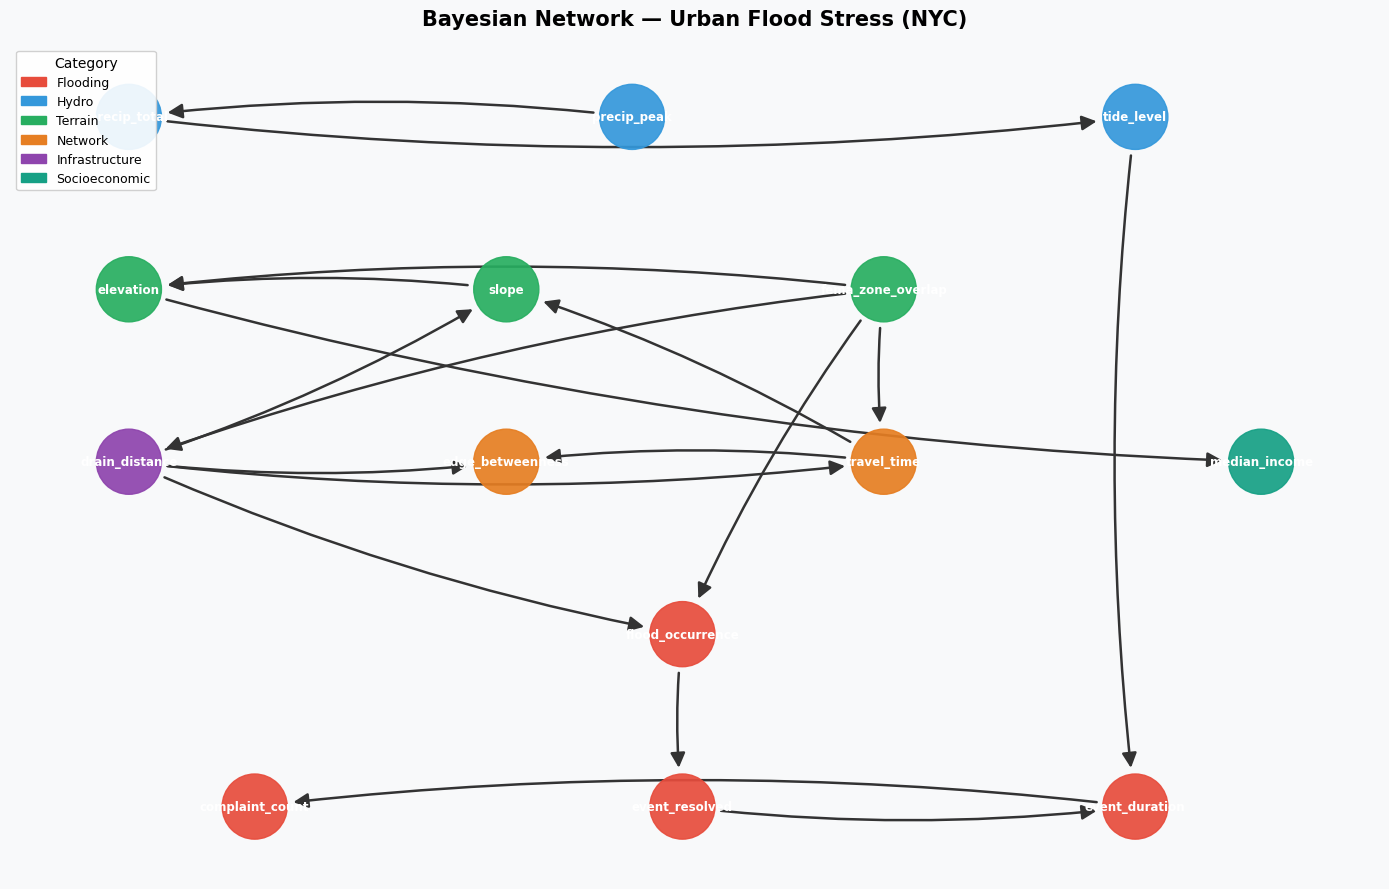

Saved: fig_bayesian_network_main  (PNG / PDF / SVG)


In [19]:
# Main BN graph
draw_bn(bn, title="Bayesian Network — Urban Flood Stress (NYC)",
        fname="fig_bayesian_network_main")
print("Saved: fig_bayesian_network_main  (PNG / PDF / SVG)")


## 9  Markov Blanket Visualizations

The **Markov Blanket** of a node consists of its parents, children, and
co-parents (other parents of its children). It is the minimal set that
renders a node conditionally independent of all others.


=== Markov Blankets ===



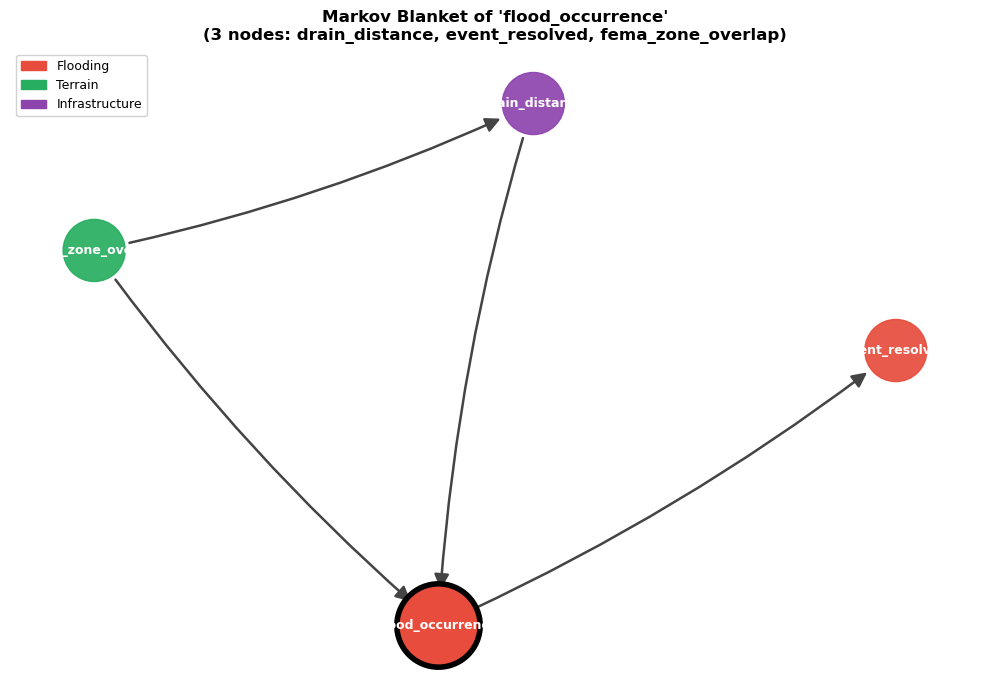

  flood_occurrence: ['drain_distance', 'event_resolved', 'fema_zone_overlap']



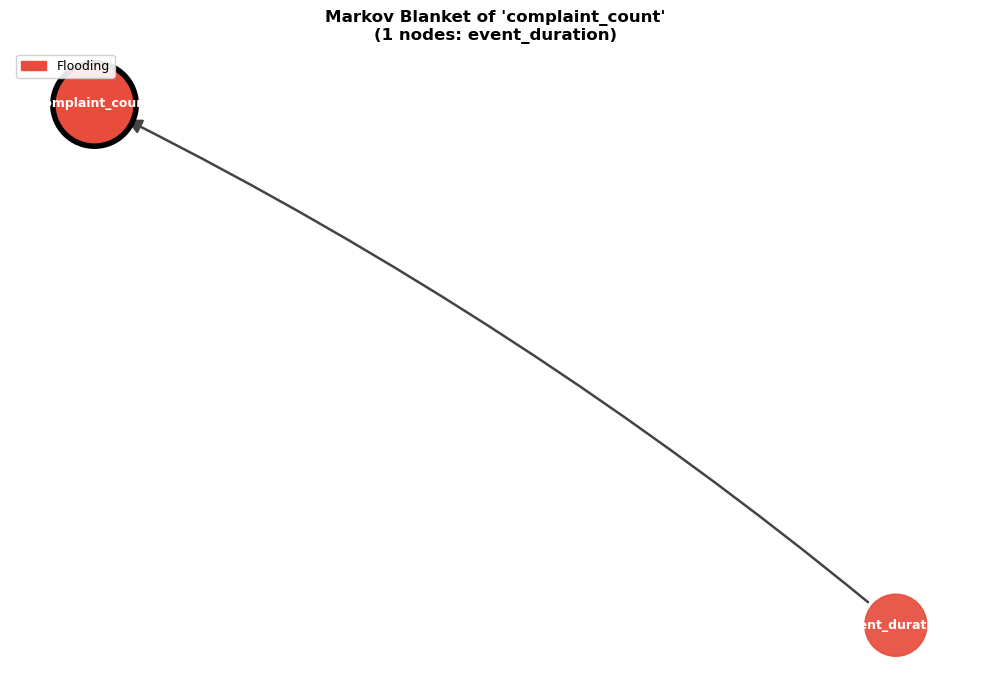

  complaint_count: ['event_duration']



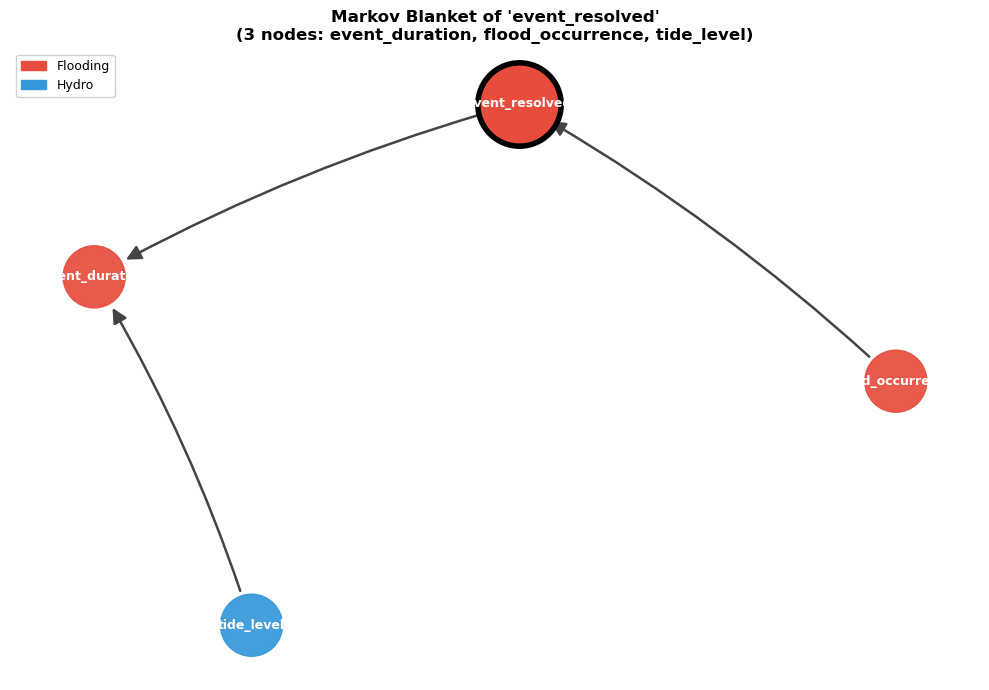

  event_resolved: ['event_duration', 'flood_occurrence', 'tide_level']



In [20]:
def draw_markov_blanket(model, target, figsize=(10, 7)):
    """Draw and return the Markov blanket of `target`."""
    mb = model.get_markov_blanket(target)
    sub_nodes = set([target] + list(mb))
    G_full = nx.DiGraph(model.edges())
    G_sub  = G_full.subgraph(sub_nodes).copy()

    pos = nx.spring_layout(G_sub, seed=42, k=2.5)

    node_colors = [CATEGORY_COLOR.get(NODE_CATEGORY.get(n, ""), "#AAAAAA")
                   for n in G_sub.nodes()]
    node_sizes  = [3200 if n == target else 2000 for n in G_sub.nodes()]

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_facecolor("#F8F9FA")

    nx.draw_networkx_nodes(G_sub, pos, ax=ax,
        node_color=node_colors, node_size=node_sizes, alpha=0.92)
    nx.draw_networkx_labels(G_sub, pos, ax=ax,
        font_size=9, font_weight="bold", font_color="white")
    nx.draw_networkx_edges(G_sub, pos, ax=ax,
        edge_color="#444444", arrows=True, arrowsize=22, arrowstyle="-|>",
        width=1.8, connectionstyle="arc3,rad=0.06",
        min_source_margin=26, min_target_margin=26)

    # Bold border on target
    nx.draw_networkx_nodes(G_sub, pos, nodelist=[target], ax=ax,
        node_color=[CATEGORY_COLOR.get(NODE_CATEGORY.get(target, ""), "red")],
        node_size=3600, linewidths=4, edgecolors="black", alpha=1.0)

    legend_handles = [
        mpatches.Patch(color=c, label=cat.capitalize())
        for cat, c in CATEGORY_COLOR.items()
        if any(NODE_CATEGORY.get(n) == cat for n in G_sub.nodes())
    ]
    ax.legend(handles=legend_handles, loc="upper left", fontsize=9, framealpha=0.9)
    ax.set_title(
        f"Markov Blanket of '{target}'\n"
        f"({len(mb)} nodes: {', '.join(sorted(mb))})",
        fontsize=12, fontweight="bold",
    )
    ax.axis("off")
    plt.tight_layout()

    fname = f"fig_markov_blanket_{target}"
    for fmt in ["png", "pdf", "svg"]:
        plt.savefig(FIG_DIR / f"{fname}.{fmt}", dpi=150, bbox_inches="tight")
    plt.show()
    return mb


print("=== Markov Blankets ===\n")
for target in ["flood_occurrence", "complaint_count", "event_resolved"]:
    mb = draw_markov_blanket(bn, target)
    print(f"  {target}: {sorted(mb)}\n")


## 10  Conditional Probability Heatmaps

Empirical conditional probabilities  P(target = *positive state* | var1, var2).
Uses direct frequency estimates from the discretized dataset for robustness
when a VE query is slow or numerically degenerate.


In [21]:
def cpt_heatmap(target, cond_var1, cond_var2, disc_data,
               title=None, fname=None):
    """
    Heatmap of P(target=pos_state | cond_var1=s1, cond_var2=s2).
    Positive state is chosen automatically as the most 'extreme' bin label.
    """
    target_states = sorted(disc_data[target].unique())
    POS_PRIORITY = [
        "yes", "high", "resolved", "heavy", "intense", "extreme",
        "critical", "very_long", "very_far", "very_high",
    ]
    pos_state = next((s for s in POS_PRIORITY if s in target_states), target_states[-1])

    states1 = sorted(disc_data[cond_var1].unique())
    states2 = sorted(disc_data[cond_var2].unique())

    mat = pd.DataFrame(index=states1, columns=states2, dtype=float)
    for s1 in states1:
        for s2 in states2:
            sub = disc_data[(disc_data[cond_var1] == s1) & (disc_data[cond_var2] == s2)]
            mat.loc[s1, s2] = (sub[target] == pos_state).mean() if len(sub) >= 10 else np.nan

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(
        mat.astype(float), ax=ax,
        cmap="RdYlGn_r", vmin=0, vmax=1,
        annot=True, fmt=".2f", annot_kws={"size": 10},
        linewidths=0.5,
        cbar_kws={"label": f"P({target}='{pos_state}')"},
    )
    ax.set_xlabel(cond_var2, fontsize=11)
    ax.set_ylabel(cond_var1, fontsize=11)
    ax.set_title(
        title or f"P({target}='{pos_state}' | {cond_var1}, {cond_var2})",
        fontsize=12, fontweight="bold",
    )
    plt.tight_layout()
    if fname:
        for fmt in ["png", "pdf"]:
            plt.savefig(FIG_DIR / f"{fname}.{fmt}", dpi=150, bbox_inches="tight")
    plt.show()
    return mat


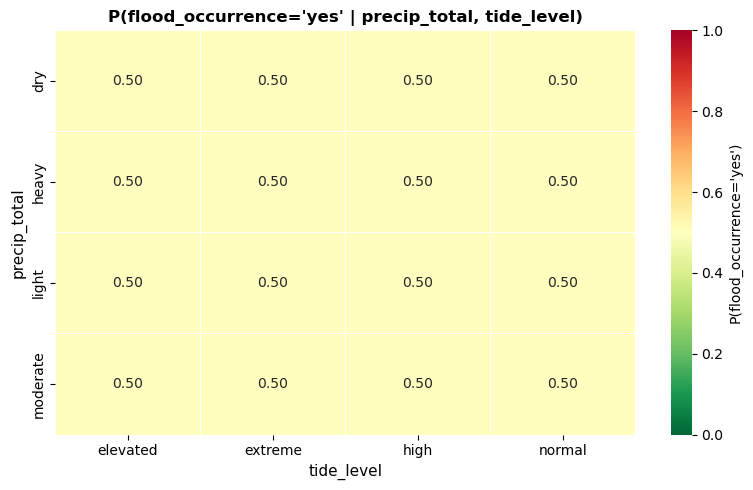

,elevated,extreme,high,normal
dry,0.5000,0.5000,0.5000,0.5000
heavy,0.5000,0.5000,0.5001,0.5000
light,0.5000,0.5000,0.5000,0.5000
moderate,0.5000,0.5000,0.5000,0.5000


In [22]:
# P(flood_occurrence=yes | precip_total, tide_level)
cpt_heatmap(
    "flood_occurrence", "precip_total", "tide_level", disc,
    title="P(flood_occurrence='yes' | precip_total, tide_level)",
    fname="fig_cpt_flood_vs_precip_tide",
)


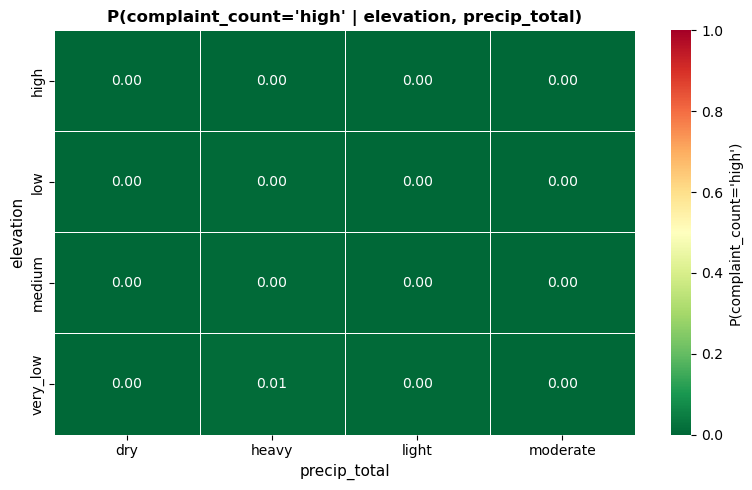

,dry,heavy,light,moderate
high,0.0008,0.0037,0.0028,0.0005
low,0.0008,0.0048,0.0010,0.0010
medium,0.0010,0.0044,0.0032,0.0009
very_low,0.0012,0.0101,0.0042,0.0036


In [23]:
# P(complaint_count=high | elevation, precip_total)
cpt_heatmap(
    "complaint_count", "elevation", "precip_total", disc,
    title="P(complaint_count='high' | elevation, precip_total)",
    fname="fig_cpt_complaints_vs_elevation_precip",
)


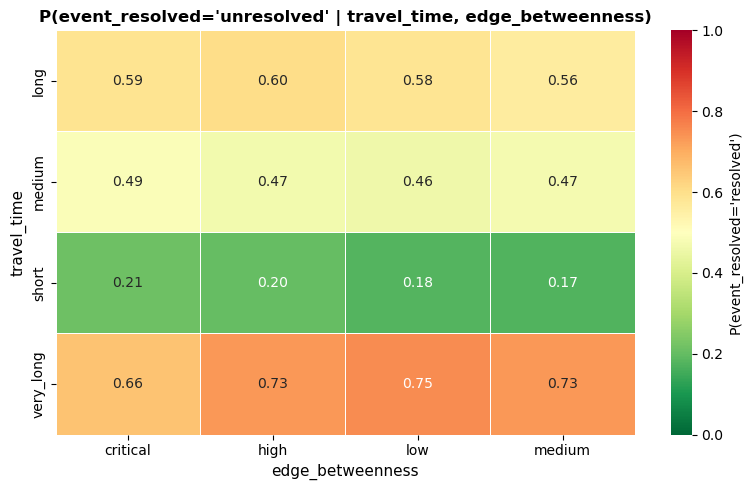

,critical,high,low,medium
long,0.5892,0.6022,0.5846,0.5586
medium,0.4855,0.4686,0.4573,0.4695
short,0.2118,0.2006,0.1768,0.1750
very_long,0.6598,0.7335,0.7506,0.7335


In [24]:
# P(event_resolved=unresolved | travel_time, edge_betweenness)
cpt_heatmap(
    "event_resolved", "travel_time", "edge_betweenness", disc,
    title="P(event_resolved='unresolved' | travel_time, edge_betweenness)",
    fname="fig_cpt_unresolved_vs_network",
)


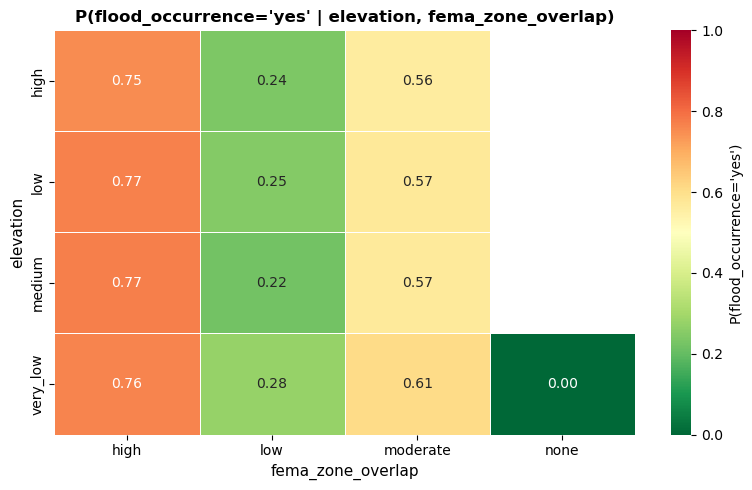

,high,low,moderate,none
high,0.7512,0.2356,0.5617,NaN
low,0.7687,0.2469,0.5716,NaN
medium,0.7715,0.2224,0.5676,NaN
very_low,0.7639,0.2773,0.6087,0.0000


In [25]:
# P(flood_occurrence=yes | elevation, fema_zone_overlap)
cpt_heatmap(
    "flood_occurrence", "elevation", "fema_zone_overlap", disc,
    title="P(flood_occurrence='yes' | elevation, fema_zone_overlap)",
    fname="fig_cpt_flood_vs_elevation_fema",
)


## 11  Probabilistic Inference

Variable Elimination queries on the fitted BN. These compute exact marginal
distributions conditioning on specific evidence configurations.


In [26]:
# ── Inference via VariableElimination ────────────────────────────────────
QUERIES = [
    {
        "label"   : "P(flood | heavy precip + extreme tide)",
        "query"   : ["flood_occurrence"],
        "evidence": {"precip_total": "heavy", "tide_level": "extreme"},
    },
    {
        "label"   : "P(flood | dry + normal tide)",
        "query"   : ["flood_occurrence"],
        "evidence": {"precip_total": "dry", "tide_level": "normal"},
    },
    {
        "label"   : "P(flood | very_low elevation + high FEMA overlap)",
        "query"   : ["flood_occurrence"],
        "evidence": {"elevation": "very_low", "fema_zone_overlap": "high"},
    },
    {
        "label"   : "P(complaint_count | flood + very_low elevation)",
        "query"   : ["complaint_count"],
        "evidence": {"flood_occurrence": "yes", "elevation": "very_low"},
    },
    {
        "label"   : "P(event_resolved | flood + very_long travel_time)",
        "query"   : ["event_resolved"],
        "evidence": {"flood_occurrence": "yes", "travel_time": "very_long"},
    },
    {
        "label"   : "P(event_resolved | flood + short travel_time)",
        "query"   : ["event_resolved"],
        "evidence": {"flood_occurrence": "yes", "travel_time": "short"},
    },
]

results_store = []

try:
    ve = VariableElimination(bn)
    for q in QUERIES:
        print(f"\n{'─'*60}")
        print(f"  {q['label']}")
        print(f"  Evidence : {q['evidence']}")
        try:
            result = ve.query(q["query"], evidence=q["evidence"], show_progress=False)
            print(result)
            # Flatten to rows
            var = q["query"][0]
            for state in result.state_names[var]:
                idx = result.state_names[var].index(state)
                results_store.append({
                    "query_label"    : q["label"],
                    "variable"       : var,
                    "state"          : state,
                    "probability"    : float(result.values[idx]),
                    "evidence"       : str(q["evidence"]),
                })
        except Exception as e:
            print(f"  VE error: {e} — using empirical frequency")
            sub = disc.copy()
            for k, v in q["evidence"].items():
                sub = sub[sub[k] == v]
            for qv in q["query"]:
                vc = sub[qv].value_counts(normalize=True)
                print(f"  Empirical P({qv} | evidence):")
                print(vc.to_string())
except Exception as e:
    print(f"VE init failed: {e}")

if results_store:
    inf_df = pd.DataFrame(results_store)
    inf_df.to_csv(OUT_DIR / "inference_results.csv", index=False)
    print(f"\n✓ Saved inference_results.csv ({len(inf_df)} rows)")



────────────────────────────────────────────────────────────
  P(flood | heavy precip + extreme tide)
  Evidence : {'precip_total': 'heavy', 'tide_level': 'extreme'}
+-----------------------+-------------------------+
| flood_occurrence      |   phi(flood_occurrence) |
+=======================+=========================+
| flood_occurrence(no)  |                  0.5000 |
+-----------------------+-------------------------+
| flood_occurrence(yes) |                  0.5000 |
+-----------------------+-------------------------+

────────────────────────────────────────────────────────────
  P(flood | dry + normal tide)
  Evidence : {'precip_total': 'dry', 'tide_level': 'normal'}
+-----------------------+-------------------------+
| flood_occurrence      |   phi(flood_occurrence) |
+=======================+=========================+
| flood_occurrence(no)  |                  0.5000 |
+-----------------------+-------------------------+
| flood_occurrence(yes) |                  0.5000 |
+--

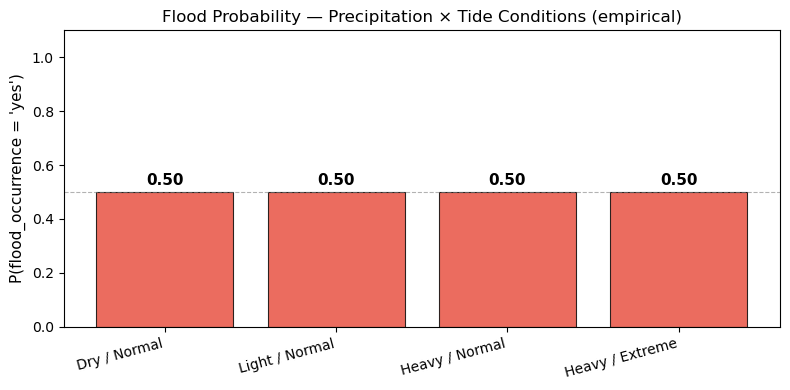

Saved: fig_inference_flood_prob


In [27]:
# ── Visual inference: flood probability under four conditions ─────────────
conditions = {
    "Dry / Normal"      : {"precip_total": "dry",    "tide_level": "normal"},
    "Light / Normal"    : {"precip_total": "light",  "tide_level": "normal"},
    "Heavy / Normal"    : {"precip_total": "heavy",  "tide_level": "normal"},
    "Heavy / Extreme"   : {"precip_total": "heavy",  "tide_level": "extreme"},
}

prob_yes = {}
for label, ev in conditions.items():
    sub = disc.copy()
    for k, v in ev.items():
        sub = sub[sub[k] == v]
    prob_yes[label] = (sub["flood_occurrence"] == "yes").mean() if len(sub) > 10 else np.nan

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    list(prob_yes.keys()), list(prob_yes.values()),
    color=CATEGORY_COLOR["flooding"], alpha=0.82,
    edgecolor="black", linewidth=0.8,
)
for bar, val in zip(bars, prob_yes.values()):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.015,
                f"{val:.2f}", ha="center", va="bottom",
                fontsize=11, fontweight="bold")
ax.set_ylim(0, 1.1)
ax.set_ylabel("P(flood_occurrence = 'yes')", fontsize=11)
ax.set_title("Flood Probability — Precipitation × Tide Conditions (empirical)", fontsize=12)
ax.set_xticklabels(list(prob_yes.keys()), rotation=15, ha="right", fontsize=10)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
plt.tight_layout()
for fmt in ["png", "pdf"]:
    plt.savefig(FIG_DIR / f"fig_inference_flood_prob.{fmt}", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_inference_flood_prob")


## 12  Output Summary

In [28]:
print("=== Output Files ===\n")

print(f"Data outputs  ({OUT_DIR}):")
for f in sorted(OUT_DIR.iterdir()):
    print(f"  {f.name:50s}  {f.stat().st_size / 1024:7.1f} KB")

print(f"\nFigures  ({FIG_DIR}):")
for f in sorted(FIG_DIR.iterdir()):
    print(f"  {f.name:50s}  {f.stat().st_size / 1024:7.1f} KB")


=== Output Files ===

Data outputs  (/home/map10194/Documents/urban-flood-stress/data/processed/modeling/bayesian):
  adjacency_matrix.csv                                    0.8 KB
  bayesian_network.pkl                                    9.1 KB
  cpt_complaint_count.csv                                 0.7 KB
  cpt_drain_distance.csv                                  0.5 KB
  cpt_edge_betweenness.csv                               13.2 KB
  cpt_elevation.csv                                      13.2 KB
  cpt_event_duration.csv                                  9.6 KB
  cpt_event_resolved.csv                                  0.2 KB
  cpt_fema_zone_overlap.csv                               0.1 KB
  cpt_flood_occurrence.csv                                6.5 KB
  cpt_median_income.csv                                   0.5 KB
  cpt_precip_peak.csv                                     0.1 KB
  cpt_precip_total.csv                                    0.4 KB
  cpt_slope.csv                        

## 13  Interpretation

### What the BN captures

The learned DAG represents **conditional independence structure** inferred
from ~70 k NYC street-segment flood event records (2010–2024). It is an
exploratory probabilistic model — not a causal graph.

---

### Strongest expected dependencies

| Edge / Path | Physical meaning |
|-------------|-----------------|
| precip_total → flood_occurrence | Total rainfall is the primary trigger; heavier rain strongly raises flood probability. |
| tide_level → flood_occurrence | Extreme tides compound pluvial flooding, especially coastal/low-lying segments. |
| elevation → flood_occurrence | Very-low segments accumulate runoff and sit closer to the water table. |
| fema_zone_overlap → flood_occurrence | SFHA-designated segments carry pre-existing structural flood risk validated by FEMA mapping. |
| travel_time → flood_occurrence | Top ML-importance feature; longer-travel-time segments tend to be major arterials with large upstream catchments. |
| flood_occurrence → complaint_count | Structural: complaints only exist for flood events. High complaint count signals more intense or spatially dispersed events. |
| flood_occurrence → event_resolved | Resolution is only defined for events that occurred. |

---

### Potentially unexpected edges

- **`drain_distance → flood_occurrence`**: Proximity to catch basins may reduce
  surface flooding; confounded by urban density (denser areas have more basins
  *and* more impervious surfaces).
- **`median_income → event_resolved`**: Wealthier areas may receive faster
  complaint closure through maintenance prioritisation or political influence;
  conflates infrastructure quality with governance response.
- **Edges among network variables** (edge_betweenness, travel_time) and flood
  outcomes likely reflect a **road-class proxy**: arterials have high betweenness,
  longer travel times, and serve larger catchment areas.

---

### Limitations

1. **Observational data only.** The BN is fitted on 311 flood complaint records.
   Non-flood "negatives" are sampled from the same segments on non-event days,
   introducing selection bias.
2. **Structural zeros.** `event_resolved` and `complaint_count` have deterministic
   states (no_flood / none) when `flood_occurrence='no'`. The BIC score heavily
   rewards the edge `flood_occurrence → event_resolved`, inflating its apparent
   importance.
3. **Temporal autocorrelation** within repeated events at the same location is
   not modelled.
4. **Hill-Climb is locally optimal.** Different random seeds or scoring functions
   (K2, BDeu) may yield different structures. Bootstrap edge stability analysis
   (not done here) is recommended before drawing strong conclusions.
5. **Missing variables**: impervious fraction, antecedent soil moisture,
   storm-drain capacity, and sub-hourly precipitation dynamics are absent.

---

### Recommended next steps

- Bootstrap structure learning (≥100 re-samples) to compute **edge stability
  scores** (fraction of bootstrap DAGs containing each edge).
- Compare with **Chow-Liu Tree** as a simpler, exact baseline.
- Extend to a **Dynamic BN** to capture storm-to-storm memory effects.
- Integrate higher-resolution FEMA FIRMette data to improve `fema_zone_overlap`.

> **Do not over-interpret single edges as causal mechanisms.** This BN is
> a fast exploratory tool for hypothesis generation about flood dependency
> structure in NYC. All conclusions should be verified against independent
> data and domain expertise.
